In [37]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 

In [38]:
df=pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [39]:
df.shape

(301, 9)

In [40]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(2)

In [42]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [43]:
numeric_cols = ['Year', 'Present_Price', 'Kms_Driven', 'Owner', 'Selling_Price']
for col in numeric_cols:
  skew=df[col].skew()
  print(f"{col}: {skew:.2f}")


Year: -1.25
Present_Price: 4.08
Kms_Driven: 6.44
Owner: 7.62
Selling_Price: 2.49


In [44]:
skew_features=['Present_Price', 'Kms_Driven', 'Selling_Price']
for col in skew_features:
  df[col]=np.log1p(df[col])

In [45]:
for col in skew_features:
  skew=df[col].skew()
  print(f"{col}: {skew:.2f}")

Present_Price: -0.05
Kms_Driven: -1.05
Selling_Price: 0.12


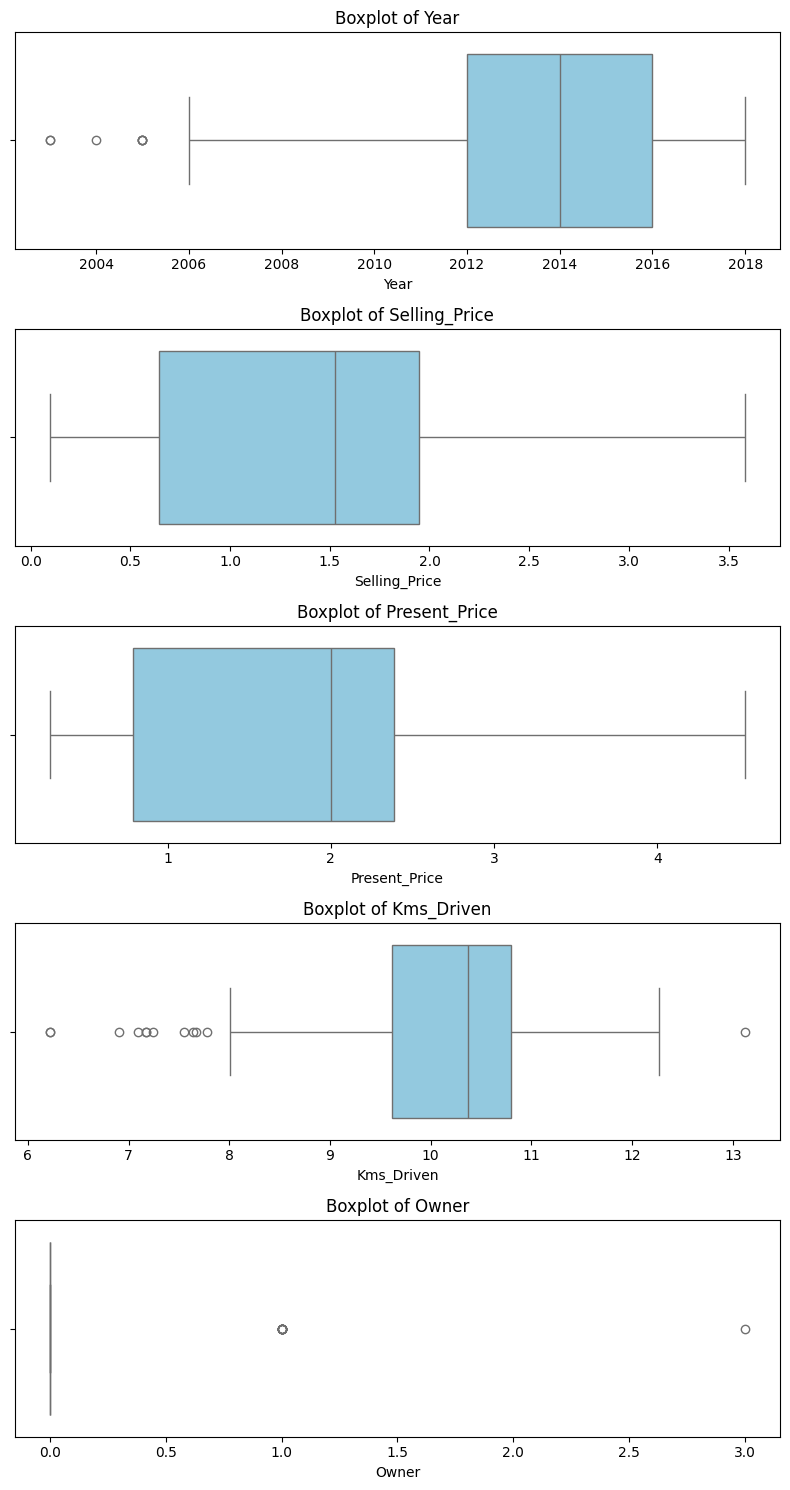

In [46]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(8, len(numeric_cols) * 3)) 
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)   
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

In [47]:
cat_cols=df.select_dtypes(include=['object']).columns
for col in cat_cols:
  print(f"{col} - ",df[col].nunique())

Car_Name -  98
Fuel_Type -  3
Seller_Type -  2
Transmission -  2


In [48]:
df.drop(['Car_Name'], axis=1, inplace=True)
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,1.470176,1.885553,10.203629,Petrol,Dealer,Manual,0
1,2013,1.749200,2.355178,10.668979,Diesel,Dealer,Manual,0
2,2017,2.110213,2.384165,8.839422,Petrol,Dealer,Manual,0
3,2011,1.348073,1.638997,8.556606,Petrol,Dealer,Manual,0
4,2014,1.722767,2.063058,10.656106,Diesel,Dealer,Manual,0


In [49]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
  df[col]=le.fit_transform(df[col])

In [50]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,1.470176,1.885553,10.203629,2,0,1,0
1,2013,1.749200,2.355178,10.668979,1,0,1,0
2,2017,2.110213,2.384165,8.839422,2,0,1,0
3,2011,1.348073,1.638997,8.556606,2,0,1,0
4,2014,1.722767,2.063058,10.656106,1,0,1,0


In [51]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
X=df.drop('Selling_Price', axis=1)
y=df['Selling_Price']
model=GradientBoostingRegressor(random_state=42)

In [52]:
param_grid={
  'learning_rate': [0.01, 0.05, 0.1],
  'n_estimators': [50, 100, 200],
  'max_depth': [2,3,4]
}
cv=KFold(n_splits=5, shuffle=True, random_state=42)
grid_search=GridSearchCV(estimator=model,
                         param_grid=param_grid,
                         cv=cv,
                         scoring='r2',
                         n_jobs=-1,
                         verbose=2)
grid_search.fit(X,y)
print(grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [53]:
from sklearn.metrics import mean_squared_error, r2_score
best_model=grid_search.best_estimator_
y_pred=best_model.predict(X)
y_pred_original=np.expm1(y_pred)
y_original=np.expm1(y)
rmse=np.sqrt(mean_squared_error(y_original, y_pred_original))
r2=r2_score(y_original, y_pred_original)
print("RMSE: ", rmse)
print("R2: ", r2)

RMSE:  0.4123389232517335
R2:  0.9933969301934319


In [54]:
import pickle as pkl
with open('car_price.pkl', 'wb') as f:
  pkl.dump((best_model, le), f)